In [1]:
from DatasetLoading import RepairDatasetLoader
from NerfRepresentationUtils import ColourPredictionPredictionNetwork
from RayRepresentationEncoding import RayRepresentationEncoder
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L
import torch
from lightning.pytorch.loggers import WandbLogger
import os

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from copy import copy

In [2]:
torch.set_float32_matmul_precision('medium')

In [3]:
def pairwise_loss(z, colours):
    """
    Args:
        z:        [B, D] latent vectors
        colours:  [B, C] colour vectors (e.g. RGB or Lab)

    Returns:
        scalar loss
    """

    # Pairwise latent distances
    z_dist = torch.cdist(z, z, p=2)  # [B, B]

    # Pairwise colour distances
    c_dist = torch.cdist(colours, colours, p=2)  # [B, B]

    # Match the geometries
    loss = (z_dist - 1 * c_dist) ** 2

    # Remove diagonal terms
    mask = ~torch.eye(z.size(0), dtype=torch.bool, device=z.device)
    loss = loss[mask]

    return loss.mean()


class TensoRFColourPrediction(L.LightningModule):
    def __init__(self, latent_size):
        super().__init__()
        self.model = ColourPredictionPredictionNetwork(latent_size)
        self.lr = 1e-4

    def pairwise_loss(self, z, colours):
        """
        Args:
            z:        [B, D] latent vectors
            colours:  [B, C] colour vectors (e.g. RGB or Lab)

        Returns:
            scalar loss
        """

        # Pairwise latent distances
        z_dist = torch.cdist(z, z, p=2)  # [B, B]

        # Pairwise colour distances
        c_dist = torch.cdist(colours, colours, p=2)  # [B, B]

        # Match the geometries
        loss = (z_dist - 1 * c_dist) ** 2

        # Remove diagonal terms
        mask = ~torch.eye(z.size(0), dtype=torch.bool, device=z.device)
        loss = loss[mask]

        return loss.mean()

    def calculate_loss(self, batch, stage):
        directions, representation, colour, weight = batch
        b1, b2, c = representation.shape
        directions, representation, colour, weight = (x.view(b1 * b2, -1) for x in (directions, representation, colour, weight))
        latent = self.model.get_latent_representation(representation)
        predicted_colour = self.model.get_colour_from_latent(latent, directions)
        loss = nn.functional.l1_loss(predicted_colour, colour)
        self.log(stage + '_loss', loss)

        pairwise_loss = self.pairwise_loss(latent, colour)
        self.log(stage + '_pairwise_loss', pairwise_loss)

        total_loss = loss + pairwise_loss
        self.log(stage + '_total_loss', total_loss)

        #self.log(stage + '_adjusted_loss', adjusted_loss)
        del predicted_colour, directions, representation, colour, weight, latent, loss, pairwise_loss
        return total_loss

    def training_step(self, batch, batch_idx):

        return self.calculate_loss(batch, stage='train')

    def test_step(self, batch, batch_idx):
        self.calculate_loss(batch, stage='test')

    def validation_step(self, batch, batch_idx):
        self.calculate_loss(batch, stage='val')


    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[23, 32, 40, 45], gamma=0.5)
        return {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "val_loss"}






In [4]:
wandb_logger = WandbLogger(project='TensoRFColourPrediction')

In [5]:
#train_ray_dataloader, test_ray_dataloader = dataset_loader.get_ray_dataloaders(batch_size=15)
dataset_loader = RepairDatasetLoader(batch_size=10, dataset_type="RawGridDataset", representation_folder_name="grids")

In [6]:
L.seed_everything(42)
model = TensoRFColourPrediction(latent_size=31)
trainer = L.Trainer(max_epochs=50, accelerator='gpu', logger=wandb_logger)
trainer.fit(model, datamodule=dataset_loader)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/enego/.netrc.
wandb: Currently logged in as: enegocomley (enegocomley-enego-couk) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type                              | Params | Mode  | FLOPs
----------------------------------------------------------------------------
0 | model | ColourPredictionPredictionNetwork | 7.7 K  | train | 0    
----------------------------------------------------------------------------
7.7 K     Trainable params
0         Non-trainable params
7.7 K     Total params
0.031     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Epoch 0: 100%|██████████| 75/75 [00:00<00:00, 180.07it/s, v_num=ei91]      
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 75/75 [00:00<00:00, 104.67it/s, v_num=ei91]    
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 75/75 [00:00<00:00, 108.48it/s, v_num=ei91]    
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 75/75 [00:00<00:00, 109.89it/s, v_num=ei91]    
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 75/75 [00:00<00:00, 113.66it/s, v_num=ei91]    
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 75/75 [00:00<00:00, 118.66it/s, v_num=ei91]    
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Ep

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 75/75 [00:01<00:00, 65.77it/s, v_num=ei91]


In [7]:
torch.save(model.model.state_dict(), os.path.join(os.getcwd(), 'TensoRFColourPrediction100PWLoss.pth'))


In [8]:
latent2representation = ColourPredictionPredictionNetwork(latent_size=31)
latent2representation.load_state_dict(torch.load("TensoRFColourPrediction100PWLoss.pth"))

<All keys matched successfully>

In [9]:
model.model = latent2representation

In [10]:
trainer.test(model, datamodule=dataset_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Testing DataLoader 0: 100%|██████████| 19/19 [00:00<00:00, 540.28it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.08864805102348328
   test_pairwise_loss       0.2016342580318451
     test_total_loss        0.29028230905532837
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.08864805102348328,
  'test_pairwise_loss': 0.2016342580318451,
  'test_total_loss': 0.29028230905532837}]

In [11]:
latent2representation

ColourPredictionPredictionNetwork(
  (representation_encoder): Sequential(
    (0): Linear(in_features=27, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=31, bias=True)
    (3): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=34, out_features=3, bias=True)
  )
)

In [12]:
model.lr

0.0001

In [14]:
test_dataset = dataset_loader.test_dataloader().dataset
idx_tensors, vals_tensor, colour_tensor, directions = test_dataset.load_raw_representation("RPf_00133.npz")
weight_adjusted_colour = colour_tensor * vals_tensor[::, :1].repeat(1, 3)
clamped_reversed_colour = 1 - torch.clamp(weight_adjusted_colour, 0, 1)

In [15]:
torch.aminmax(weight_adjusted_colour)

torch.return_types.aminmax(
min=tensor(0.),
max=tensor(1.0126))

In [16]:
torch.aminmax(colour_tensor)

torch.return_types.aminmax(
min=tensor(0.),
max=tensor(1.0165))

In [17]:
torch.aminmax(vals_tensor[::, 0])

torch.return_types.aminmax(
min=tensor(0.3086),
max=tensor(1.))

In [18]:
test_dataset.piece_names[0]

'RPf_00204.npz'

In [19]:
weight_adjusted_colour

tensor([[0.1255, 0.1251, 0.1128],
        [0.3246, 0.3203, 0.3106],
        [0.4377, 0.4210, 0.3980],
        ...,
        [0.4980, 0.4790, 0.4583],
        [0.5860, 0.5848, 0.5476],
        [0.6749, 0.6608, 0.5905]])

In [21]:
from NerfRepresentationUtils import plot_colored_voxels

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

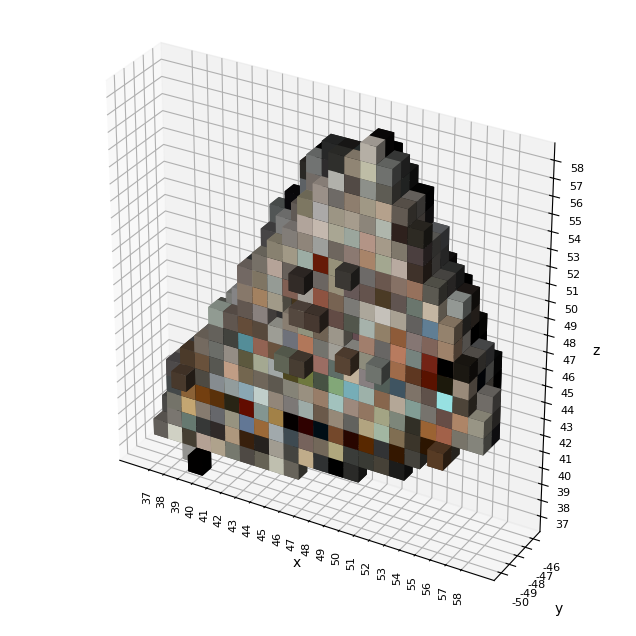

In [37]:
plot_colored_voxels(idx_tensors, weight_adjusted_colour, axis_names=['x', 'y', 'z'])

In [27]:
len(idx_tensors[0])

844

In [31]:
halved_ids = idx_tensors[0] > 50
halved_tensors = [x[halved_ids] for x in idx_tensors]
halved_colours = colour_tensor[halved_ids]

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

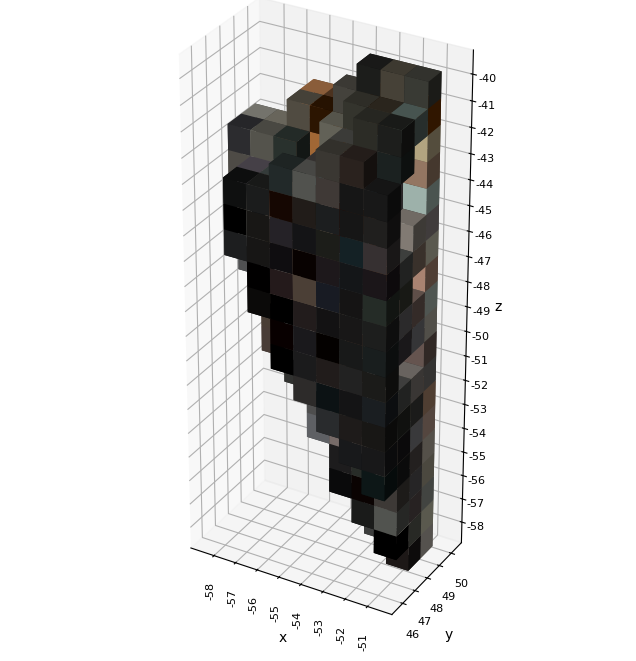

In [32]:
plot_colored_voxels([x * -1 for x in halved_tensors], halved_colours, axis_names=['x', 'y', 'z'])

In [33]:
halved_ids

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent2representation = copy(dataset_loader.latent2representation).to(device)
latent2representation.eval()

ColourPredictionPredictionNetwork(
  (representation_encoder): Sequential(
    (0): Linear(in_features=27, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=31, bias=True)
    (3): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=34, out_features=3, bias=True)
  )
)

In [35]:
pieces = dataset_loader.test_pieces + dataset_loader.val_pieces + dataset_loader.train_pieces
os.makedirs(dataset_loader.representation_data_dir + "withRepresentation", exist_ok=True)

In [36]:
for piece in pieces:
    if not os.path.exists(os.path.join(dataset_loader.representation_data_dir, piece)):
        continue
    data = dict(np.load(os.path.join(dataset_loader.representation_data_dir, piece)).items())

    values = data['values']
    alphas = values[:, :1]
    latent = values[:, 1:]
    latent_tensor = torch.from_numpy(latent).to(device)
    with torch.no_grad():
        representation_tensor = latent2representation.get_latent_representation(latent_tensor)
    representation = representation_tensor.cpu().numpy()
    data.pop('values')
    data.update({'representation': representation})
    data.update({'alphas': alphas})
    np.savez(os.path.join(dataset_loader.representation_data_dir + "withRepresentation", piece), **data)
    del representation_tensor, latent_tensor, data, representation, alphas, latent, values